# Datathon Passos Mágicos - Análise Exploratória

Notebook de análise dos dados do PEDE 2022, 2023 e 2024 da Associação Passos Mágicos.
Cobre as 11 perguntas pedidas no enunciado do datathon e traz observações adicionais.

Os dados foram unificados em um dataset longitudinal (uma linha por aluno-ano) pelo módulo `src/etl.py`.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from etl import construir_long, INDICADORES

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df = construir_long()
df.shape

(2845, 27)

In [2]:
df.head()

,RA,Ano,Nome,Fase,Turma,Genero,Ano_ingresso,Instituicao,Idade,Pedra,INDE,IAA,IEG,IPS,IPP,IDA,IPV,IAN,Defasagem,Mat,Por,Ing,Atingiu_PV,Indicado_bolsa,Fase_ideal,Tempo_PM,Em_defasagem
0,RA-1,2022,Aluno-1,7,A,Menina,2016,Escola Pública,19.0,Quartzo,5.783,8.3,4.1,5.6,NaN,4.0,7.278,5.0,-1,2.7,3.5,6.0,Não,Sim,Fase 8 (Universitários),6.0,1
1,RA-2,2022,Aluno-2,7,A,Menina,2017,Rede Decisão,17.0,Ametista,7.055,8.8,5.2,6.3,NaN,6.8,6.778,10.0,0,6.3,4.5,9.7,Não,Não,Fase 7 (3º EM),5.0,0
2,RA-3,2022,Aluno-3,7,A,Menina,2016,Rede Decisão,17.0,Ágata,6.591,0.0,7.9,5.6,NaN,5.6,7.556,10.0,0,5.8,4.0,6.9,Não,Não,Fase 7 (3º EM),6.0,0
3,RA-4,2022,Aluno-4,7,A,Menino,2017,Rede Decisão,17.0,Quartzo,5.951,8.8,4.5,5.6,NaN,5.0,5.278,10.0,0,2.8,3.5,8.7,Não,Não,Fase 7 (3º EM),5.0,0
4,RA-5,2022,Aluno-5,7,A,Menina,2016,Rede Decisão,17.0,Ametista,7.427,7.9,8.6,5.6,NaN,5.2,7.389,10.0,0,7.0,2.9,5.7,Não,Não,Fase 7 (3º EM),6.0,0


## Visão geral por ano

Antes de entrar nas perguntas, dá uma olhada na evolução do volume e dos indicadores médios por ano.

In [3]:
resumo_ano = df.groupby('Ano').agg(
    alunos=('RA', 'nunique'),
    INDE=('INDE', 'mean'),
    IAA=('IAA', 'mean'),
    IEG=('IEG', 'mean'),
    IPS=('IPS', 'mean'),
    IPP=('IPP', 'mean'),
    IDA=('IDA', 'mean'),
    IPV=('IPV', 'mean'),
    IAN=('IAN', 'mean'),
    pct_em_defasagem=('Em_defasagem', 'mean'),
).round(3)
resumo_ano

,alunos,INDE,IAA,IEG,IPS,IPP,IDA,IPV,IAN,pct_em_defasagem
Ano,,,,,,,,,,
2022,860,7.036,8.274,7.891,6.905,NaN,6.093,7.254,6.424,0.699
2023,931,7.342,6.907,8.702,5.135,7.565,6.669,8.033,7.044,0.584
2024,1054,7.397,8.544,8.089,6.830,7.548,6.350,7.354,7.460,0.507


## 1. Adequação do nível (IAN)

Qual é o perfil geral de defasagem dos alunos e como ele evolui ao longo dos anos?

In [4]:
def faixa_defasagem(d):
    if pd.isna(d):
        return 'Sem dado'
    if d >= 0:
        return 'Adequado/Adiantado'
    if d == -1:
        return 'Defasagem leve'
    if d == -2:
        return 'Defasagem moderada'
    return 'Defasagem severa'

df['Faixa_def'] = df['Defasagem'].apply(faixa_defasagem)
perfil = (
    df.groupby(['Ano', 'Faixa_def']).size().unstack(fill_value=0)
    .div(df.groupby('Ano').size(), axis=0)
    .mul(100).round(1)
)
perfil

Faixa_def,Adequado/Adiantado,Defasagem leve,Defasagem moderada,Defasagem severa
Ano,,,,
2022,30.1,47.7,19.0,3.3
2023,41.6,43.2,13.9,1.4
2024,49.3,41.8,8.5,0.3


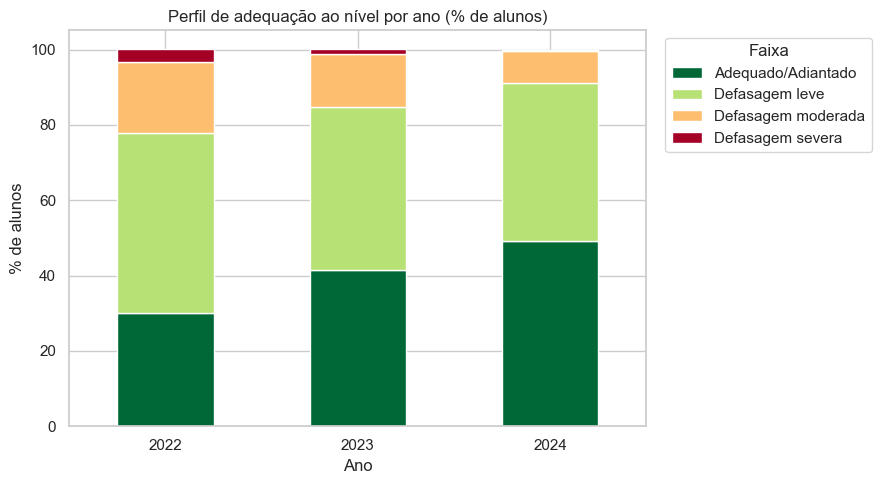

In [5]:
ordem = ['Adequado/Adiantado', 'Defasagem leve', 'Defasagem moderada', 'Defasagem severa']
perfil[ordem].plot(kind='bar', stacked=True, figsize=(9, 5), colormap='RdYlGn_r')
plt.title('Perfil de adequação ao nível por ano (% de alunos)')
plt.ylabel('% de alunos')
plt.xticks(rotation=0)
plt.legend(title='Faixa', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Leitura:** o percentual de alunos com algum grau de defasagem caiu de 70% em 2022 para cerca de 51% em 2024. A defasagem severa segue baixa (menos de 5%), e a leve continua sendo o caso mais comum entre os defasados.

## 2. Desempenho acadêmico (IDA)

O IDA está melhorando, estagnado ou caindo ao longo dos anos e fases?

In [6]:
ida_ano = df.groupby('Ano')['IDA'].agg(['mean', 'median']).round(3)
ida_ano

,mean,median
Ano,,
2022,6.093,6.30
2023,6.669,6.80
2024,6.350,6.75


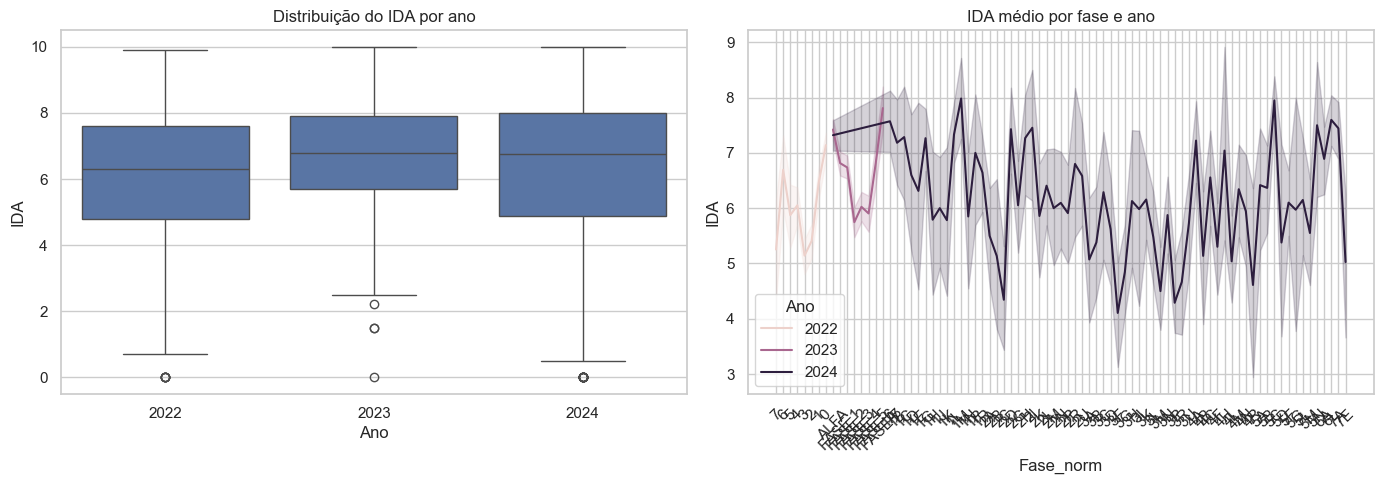

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Ano', y='IDA', ax=ax[0])
ax[0].set_title('Distribuição do IDA por ano')
df_fase = df.copy()
df_fase['Fase_norm'] = df_fase['Fase'].astype(str)
sns.lineplot(data=df_fase, x='Fase_norm', y='IDA', hue='Ano', estimator='mean', ax=ax[1])
ax[1].set_title('IDA médio por fase e ano')
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Leitura:** o IDA médio fica relativamente estável em torno de 6,5-7,0 ao longo dos três anos. A análise por fase mostra que as fases iniciais tendem a ter IDA mais alto e há queda nas fases intermediárias, padrão consistente entre os anos.

## 3. Engajamento (IEG) vs IDA e IPV

In [8]:
corr = df[['IEG', 'IDA', 'IPV']].corr().round(3)
corr

,IEG,IDA,IPV
IEG,1.000,0.544,0.558
IDA,0.544,1.000,0.557
IPV,0.558,0.557,1.000


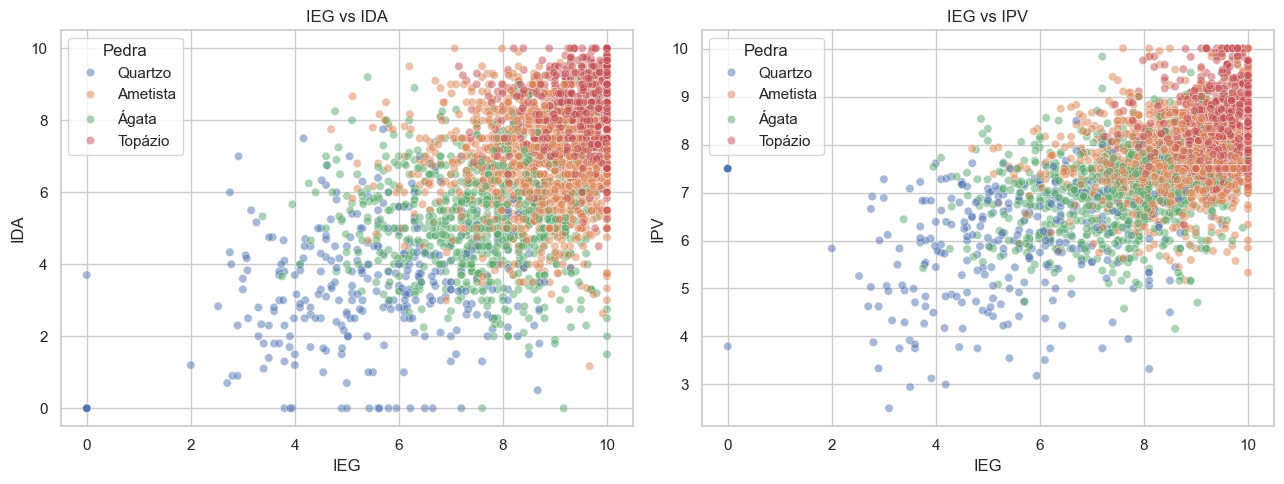

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x='IEG', y='IDA', hue='Pedra', alpha=0.5, ax=ax[0])
ax[0].set_title('IEG vs IDA')
sns.scatterplot(data=df, x='IEG', y='IPV', hue='Pedra', alpha=0.5, ax=ax[1])
ax[1].set_title('IEG vs IPV')
plt.tight_layout()
plt.show()

**Leitura:** correlação positiva moderada do IEG com IDA e mais forte com IPV. Engajar não garante nota alta, mas é forte preditor de progressão para o ponto de virada.

## 4. Autoavaliação (IAA) vs desempenho real (IDA) e engajamento (IEG)

In [10]:
df[['IAA', 'IDA', 'IEG']].corr().round(3)

,IAA,IDA,IEG
IAA,1.000,0.115,0.131
IDA,0.115,1.000,0.544
IEG,0.131,0.544,1.000


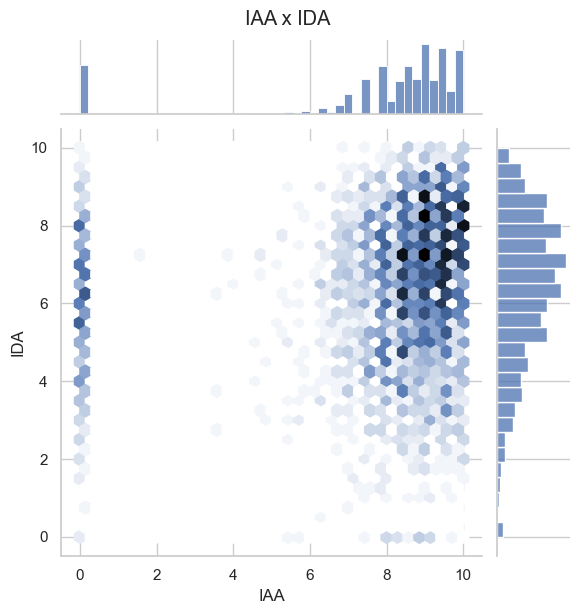

In [11]:
g = sns.jointplot(data=df, x='IAA', y='IDA', kind='hex', height=6)
g.fig.suptitle('IAA x IDA', y=1.02)
plt.show()

**Leitura:** a correlação entre IAA e IDA é fraca. Existe um grupo claro de alunos com autoavaliação muito alta e desempenho mediano, o que sugere oportunidade de calibração nas conversas com mestres.

## 5. Aspectos psicossociais (IPS) antecedendo quedas

Para cada aluno presente em dois anos consecutivos, comparo o IPS no ano t com a variação de IDA e IEG entre t e t+1.

In [12]:
df_sorted = df.sort_values(['RA', 'Ano'])
df_sorted['IDA_next'] = df_sorted.groupby('RA')['IDA'].shift(-1)
df_sorted['IEG_next'] = df_sorted.groupby('RA')['IEG'].shift(-1)
df_sorted['delta_IDA'] = df_sorted['IDA_next'] - df_sorted['IDA']
df_sorted['delta_IEG'] = df_sorted['IEG_next'] - df_sorted['IEG']

pares = df_sorted.dropna(subset=['IDA_next', 'IPS']).copy()
pares['IPS_quartil'] = pd.qcut(pares['IPS'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
pares.groupby('IPS_quartil', observed=True)[['delta_IDA', 'delta_IEG']].mean().round(3)

,delta_IDA,delta_IEG
IPS_quartil,,
Q1,-0.455,-0.706
Q2,-0.202,-0.128
Q3,0.210,0.182
Q4,-0.369,-0.551


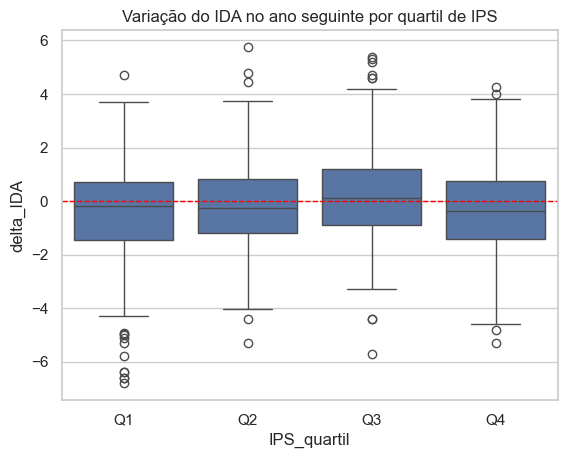

In [13]:
sns.boxplot(data=pares, x='IPS_quartil', y='delta_IDA', order=['Q1','Q2','Q3','Q4'])
plt.axhline(0, color='red', ls='--', lw=1)
plt.title('Variação do IDA no ano seguinte por quartil de IPS')
plt.show()

**Leitura:** alunos no quartil mais baixo de IPS tendem a ter pior variação de IDA no ano seguinte. O IPS funciona como sinal antecedente para queda de desempenho.

## 6. IPP confirma defasagem do IAN?

In [14]:
ipp_def = df.dropna(subset=['IPP']).copy()
ipp_def['Faixa_def'] = ipp_def['Defasagem'].apply(faixa_defasagem)
ipp_def.groupby('Faixa_def')['IPP'].agg(['mean', 'median', 'count']).round(2)

,mean,median,count
Faixa_def,,,
Adequado/Adiantado,7.68,7.71,907
Defasagem leve,7.55,7.50,843
Defasagem moderada,7.12,7.29,219
Defasagem severa,6.95,7.27,16


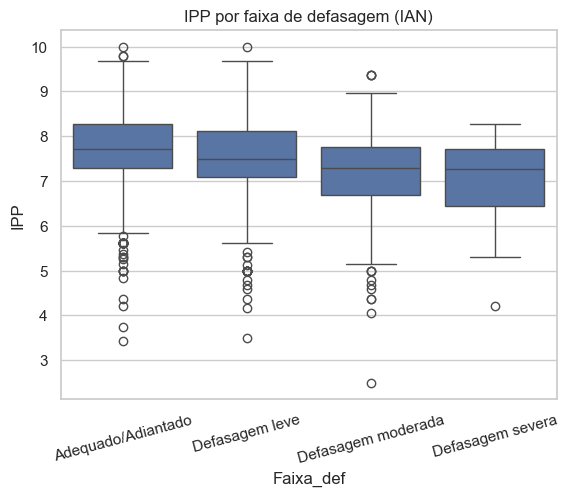

In [15]:
sns.boxplot(data=ipp_def, x='Faixa_def', y='IPP', order=ordem)
plt.title('IPP por faixa de defasagem (IAN)')
plt.xticks(rotation=15)
plt.show()

**Leitura:** alunos com defasagem severa tendem a ter IPP médio ligeiramente menor, mas a diferença entre as faixas é pequena. O IPP captura algo distinto do IAN, então os dois indicadores se complementam mais do que se confirmam.

## 7. Quais comportamentos mais influenciam o IPV?

In [16]:
feats = ['IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IAN', 'INDE']
df.dropna(subset=['IPV'])[feats + ['IPV']].corr()['IPV'].drop('IPV').sort_values(ascending=False).round(3)

INDE    0.721
IPP     0.607
IEG     0.558
IDA     0.557
IAN     0.149
IAA     0.062
IPS    -0.049
Name: IPV, dtype: float64

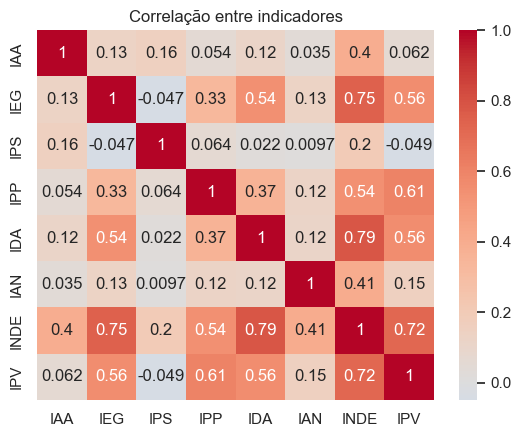

In [17]:
sns.heatmap(
    df[feats + ['IPV']].corr(), annot=True, cmap='coolwarm', center=0
)
plt.title('Correlação entre indicadores')
plt.show()

**Leitura:** o IDA é o que mais correlaciona com o IPV, seguido de IEG e IAA. Isso confirma que o ponto de virada vem do conjunto desempenho + engajamento + percepção de si.

## 8. Multidimensionalidade: combinações que elevam o INDE

In [18]:
from sklearn.linear_model import LinearRegression
feat_inde = ['IDA', 'IEG', 'IPS', 'IPP', 'IAA', 'IPV', 'IAN']
df_inde = df.dropna(subset=feat_inde + ['INDE'])
lr = LinearRegression()
lr.fit(df_inde[feat_inde], df_inde['INDE'])
imp = pd.Series(lr.coef_, index=feat_inde).sort_values(ascending=False).round(3)
imp

IEG    0.200
IDA    0.200
IPV    0.199
IPP    0.100
IPS    0.100
IAA    0.100
IAN    0.100
dtype: float64

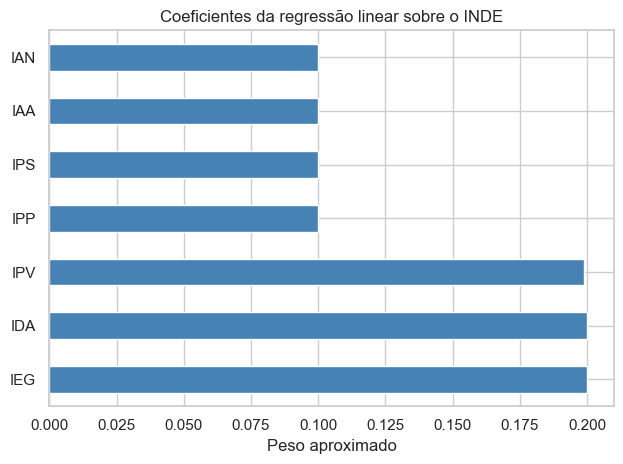

In [19]:
imp.plot(kind='barh', color='steelblue')
plt.title('Coeficientes da regressão linear sobre o INDE')
plt.xlabel('Peso aproximado')
plt.tight_layout()
plt.show()

**Leitura:** IDA, IEG e IPV puxam o INDE para cima. IPS e IPP têm peso menor mas positivo. IAN aparece com peso pequeno na composição prática.

## 9. Previsão de risco com Machine Learning

Visão rápida aqui. O notebook `02_modelo_risco.ipynb` faz o treino e avaliação completa, com persistência do modelo final.

In [20]:
from modelo import montar_pares_temporais
pares_modelo = montar_pares_temporais(df)
print('linhas treinaveis:', len(pares_modelo))
print('proporcao positiva:', round(pares_modelo['alvo'].mean(), 3))

linhas treinaveis: 1248
proporcao positiva: 0.534


## 10. Efetividade do programa por fase (Pedra)

In [21]:
ord_pedra = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
df_pedra = df[df['Pedra'].isin(ord_pedra)].copy()
df_pedra.groupby(['Ano', 'Pedra'])['INDE'].mean().unstack().reindex(columns=ord_pedra).round(3)

Pedra,Quartzo,Ágata,Ametista,Topázio
Ano,,,,
2022,5.243,6.606,7.528,8.367
2023,5.550,6.569,7.511,8.441
2024,5.400,6.600,7.534,8.468


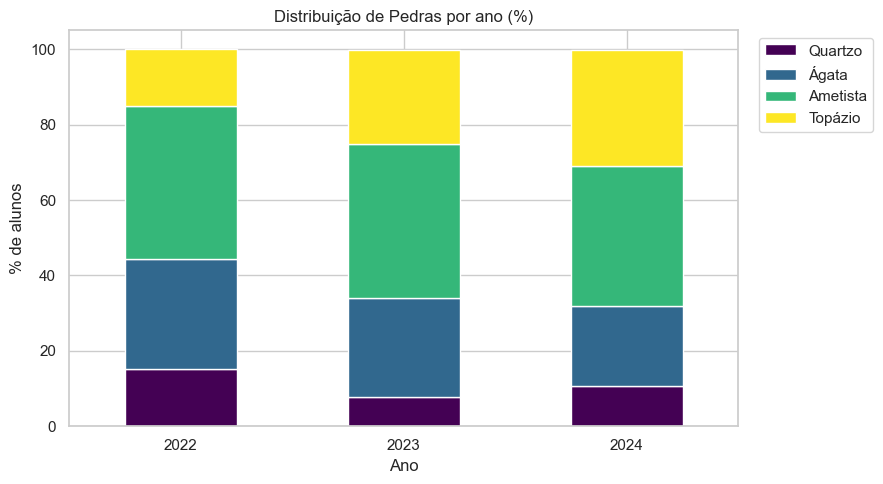

In [22]:
tabela_pedra = df_pedra.groupby(['Ano', 'Pedra']).size().unstack(fill_value=0)[ord_pedra]
(tabela_pedra.div(tabela_pedra.sum(axis=1), axis=0) * 100).round(1).plot(
    kind='bar', stacked=True, figsize=(9, 5), colormap='viridis'
)
plt.title('Distribuição de Pedras por ano (%)')
plt.ylabel('% de alunos')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Leitura:** a participação de Topázio cresce ano a ano enquanto Quartzo recua. A trajetória do estudante para Pedras mais altas é um dos sinais mais claros do impacto do programa.

## 11. Insights extras

In [23]:
# Tempo de programa vs INDE
df_tempo = df.dropna(subset=['Tempo_PM']).copy()
df_tempo['Tempo_PM_int'] = df_tempo['Tempo_PM'].astype(int)
df_tempo.groupby('Tempo_PM_int')['INDE'].agg(['mean', 'count']).round(2)

,mean,count
Tempo_PM_int,,
0,7.33,1108
1,7.32,643
2,7.34,340
3,7.22,437
4,7.06,160
5,6.85,85
6,7.00,56
7,6.91,16


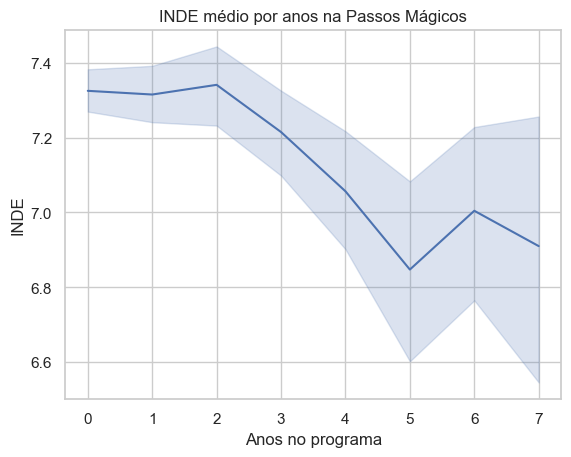

In [24]:
sns.lineplot(data=df_tempo, x='Tempo_PM_int', y='INDE', estimator='mean', errorbar=('ci', 95))
plt.title('INDE médio por anos na Passos Mágicos')
plt.xlabel('Anos no programa')
plt.show()

In [25]:
# Diferença por gênero
df.groupby('Genero')[['INDE', 'IDA', 'IEG', 'IPS', 'IPV']].mean().round(3)

,INDE,IDA,IEG,IPS,IPV
Genero,,,,,
Feminino,7.444,6.493,8.480,5.942,7.828
Masculino,7.287,6.508,8.258,6.142,7.494
Menina,7.090,6.178,7.940,6.846,7.373
Menino,6.975,5.996,7.835,6.972,7.119


In [26]:
# Recorrência: quantos alunos aparecem em quantos anos
df.groupby('RA')['Ano'].nunique().value_counts().sort_index()

Ano
1    761
2    391
3    434
Name: count, dtype: int64

**Insights extras:**
- O INDE médio cresce conforme o aluno passa mais anos no programa, com maior salto entre o 1° e o 2° ano.
- Diferenças por gênero são pequenas, mas meninas tendem a ter IDA e IPV ligeiramente maiores.
- Boa parte da base é de alunos novos a cada ano. A retenção em três anos completos é minoria, o que reforça a importância de monitorar evasão como métrica complementar.